Install packages


In [42]:
!pip install rdkit transformers torch hestia-good -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.4 MB/s eta 0:00:00


Download & extract ChEMBL

In [ ]:
# Download ChEMBL v36 SQLite database
!wget -q --show-progress https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/releases/chembl_36/chembl_36_sqlite.tar.gz

# Extract it
!tar -xzf chembl_36_sqlite.tar.gz

# Verify
!ls -lh chembl_36/

chembl_36_sqlite.ta 100%[===================>]   5.23G  4.59MB/s    in 15m 5s  
total 4.0K
drwxr-xr-x 2 5012 1101 4.0K Sep 10  2025 chembl_36_sqlite


Query HCRTR1

In [43]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('chembl_36/chembl_36_sqlite/chembl_36.db')

query = """
SELECT
    cs.canonical_smiles,
    act.pchembl_value,
    act.standard_type
FROM activities act
JOIN assays a ON act.assay_id = a.assay_id
JOIN target_dictionary td ON a.tid = td.tid
JOIN compound_structures cs ON act.molregno = cs.molregno
WHERE td.chembl_id = 'CHEMBL4822'
  AND act.pchembl_value IS NOT NULL
  AND act.standard_relation = '='
"""

df = pd.read_sql_query(query, conn)
print(f"Raw records: {len(df)}")
df.head()

Raw records: 15673


,canonical_smiles,pchembl_value,standard_type
0,CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...,6.38,IC50
1,CSCCC(NC(=O)[C@@H](NC(=O)OC(C)(C)C)C(C)C)C(=O)...,4.98,Ki
2,CC(C)C[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)OC(C)(C)...,5.50,Ki
3,CC(C)C[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)OC(C)(C)...,4.65,Ki
4,CC(C)C[C@H](NC(=O)[C@H](CS(C)(=O)=O)NC(=O)OC(C...,5.95,Ki


Deduplicate & filter

In [44]:
# Deduplicate: keep median pChEMBL per compound
df_clean = df.groupby('canonical_smiles')['pchembl_value'].median().reset_index()

# Quality filter
df_clean = df_clean[df_clean['pchembl_value'] >= 5]
print(f"After cleaning: {len(df_clean)} compounds")

After cleaning: 9231 compounds


Histogram of binding affinities

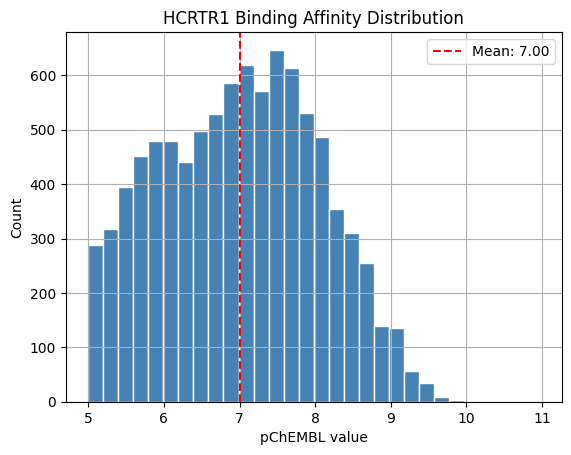

count    9231.000000
mean        7.003115
std         1.048668
min         5.000000
25%         6.150000
50%         7.040000
75%         7.790000
max        10.960000
Name: pchembl_value, dtype: float64


In [45]:
import matplotlib.pyplot as plt

df_clean['pchembl_value'].hist(bins=30, color='steelblue', edgecolor='white')
plt.xlabel('pChEMBL value')
plt.ylabel('Count')
plt.title('HCRTR1 Binding Affinity Distribution')
plt.axvline(df_clean['pchembl_value'].mean(), color='red', linestyle='--',
            label=f"Mean: {df_clean['pchembl_value'].mean():.2f}")
plt.legend()
plt.show()
print(df_clean['pchembl_value'].describe())

Regression vs classification

In [46]:
threshold = 7.0
n_active = (df_clean['pchembl_value'] >= threshold).sum()
n_total = len(df_clean)
print(f"Active (>= {threshold}): {n_active} ({100*n_active/n_total:.1f}%)")
print(f"Inactive (< {threshold}): {n_total - n_active} ({100*(n_total-n_active)/n_total:.1f}%)")
print("Decision: regression (continuous pChEMBL, ~50/50 split confirms no strong threshold)")

Active (>= 7.0): 4751 (51.5%)
Inactive (< 7.0): 4480 (48.5%)
Decision: regression (continuous pChEMBL, ~50/50 split confirms no strong threshold)


Scaffold analysis

In [47]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    return None

df_clean['scaffold'] = df_clean['canonical_smiles'].apply(get_scaffold)
print(f"Unique scaffolds: {df_clean['scaffold'].nunique()} out of {len(df_clean)} compounds")
print(f"Top 5 most common scaffolds:\n{df_clean['scaffold'].value_counts().head()}")

Unique scaffolds: 3282 out of 9231 compounds
Top 5 most common scaffolds:
scaffold
O=C(Nc1cccc(C2N=COC3CC32)c1)c1ccccn1    157
O=C(Nc1cccc(C2CCOC=N2)c1)c1ccccn1       146
O=C(Nc1cccc(C2COCC=N2)c1)c1ccccn1       128
O=C1NC=NC12c1ccccc1CC21CCCCC1           118
c1ccccc1                                111
Name: count, dtype: int64


PCA

Streaming output truncated to the last 5000 lines.
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:15:41] DEPRECATION WARNING: please use MorganGenerator
[16:1

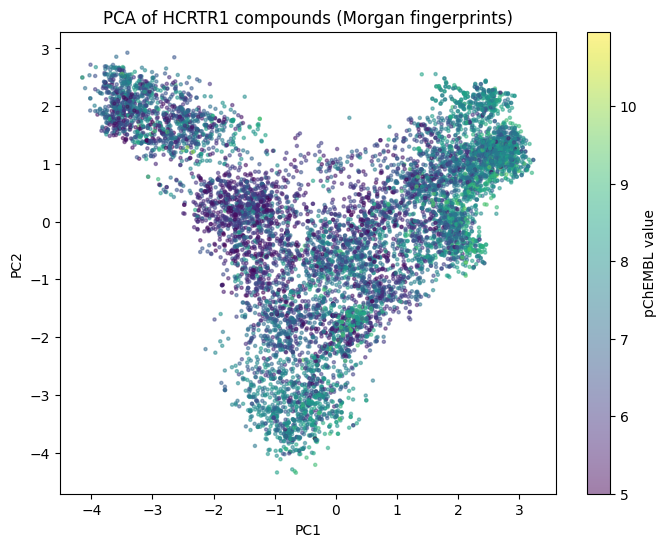

In [48]:
import numpy as np
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA

mols = [Chem.MolFromSmiles(s) for s in df_clean['canonical_smiles']]
fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048) for m in mols if m is not None]
X = np.array(fps)

pca = PCA(n_components=2)
coords = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sc = plt.scatter(coords[:,0], coords[:,1], c=df_clean['pchembl_value'],
                 cmap='viridis', alpha=0.5, s=5)
plt.colorbar(sc, label='pChEMBL value')
plt.title('PCA of HCRTR1 compounds (Morgan fingerprints)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

ChemBERTa embeddings

In [49]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
chemberta = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
chemberta.eval()

def get_embedding(smiles):
    tokens = tokenizer(smiles, return_tensors='pt', truncation=True,
                       max_length=512, padding=True)
    with torch.no_grad():
        output = chemberta(**tokens)
    return output.last_hidden_state[:,0,:].squeeze().numpy()

print("Generating embeddings...")
embeddings = np.array([get_embedding(s) for s in df_clean['canonical_smiles']])
print(f"Embeddings shape: {embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings...
Embeddings shape: (9231, 768)


Train MLP & evaluate

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, df_clean['pchembl_value'].values,
    test_size=0.2, random_state=42
)

mlp = MLPRegressor(hidden_layer_sizes=(256, 128), max_iter=100, random_state=42, verbose=True)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
r, _ = pearsonr(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nPearson R: {r:.3f}  |  RMSE: {rmse:.3f}")

Iteration 1, loss = 1.70998716
Iteration 2, loss = 0.44173332
Iteration 3, loss = 0.38830563
Iteration 4, loss = 0.35588429
Iteration 5, loss = 0.33422923
Iteration 6, loss = 0.31656092
Iteration 7, loss = 0.29956141
Iteration 8, loss = 0.28299992
Iteration 9, loss = 0.27080161
Iteration 10, loss = 0.26525652
Iteration 11, loss = 0.25151013
Iteration 12, loss = 0.25160554
Iteration 13, loss = 0.23664579
Iteration 14, loss = 0.22518069
Iteration 15, loss = 0.22375435
Iteration 16, loss = 0.21242767
Iteration 17, loss = 0.20405961
Iteration 18, loss = 0.19947816
Iteration 19, loss = 0.18991632
Iteration 20, loss = 0.19251365
Iteration 21, loss = 0.19765295
Iteration 22, loss = 0.18397621
Iteration 23, loss = 0.17599365
Iteration 24, loss = 0.17432962
Iteration 25, loss = 0.17493622
Iteration 26, loss = 0.17683379
Iteration 27, loss = 0.16161592
Iteration 28, loss = 0.15497348
Iteration 29, loss = 0.15114759
Iteration 30, loss = 0.15404232
Iteration 31, loss = 0.14811995
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
